# Step 5 — Train the Medical GPT Model
**Medical Chatbot | GPT-style Autoregressive Training**

| Parameter | Value |
|-----------|-------|
| Batch size | 64 |
| Epochs | 15-20 (early stopping) |
| Optimizer | Adam |
| Loss | Cross Entropy (ignore padding) |
| LR Schedule | Warmup + Cosine Decay |
| Gradient Clipping | max_norm = 1.0 |

In [34]:
# ─────────────────────────────────────────────
# EXPERIMENT CONFIG — change this every new run!
# ─────────────────────────────────────────────
EXPERIMENT_NAME  = "exp4_d512_heads2_layers8"
EXPERIMENT_NOTES = "d_model=512, 2 heads, 8 layers "

## Cell 1 — Imports

In [35]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math
import json
import os
import time
import matplotlib.pyplot as plt

print('PyTorch version :', torch.__version__)
print('CUDA available  :', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU             :', torch.cuda.get_device_name(0))
    print('VRAM            :', round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1), 'GB')

PyTorch version : 2.5.1+cu121
CUDA available  : True
GPU             : NVIDIA GeForce RTX 4060 Ti
VRAM            : 15.6 GB


## Cell 2 — Load Config

In [36]:
with open('../tokenizer/config.json', 'r') as f:
    config = json.load(f)

# ── Experiment Overrides — change these for each experiment ──
N_HEADS  = 2   # change this
N_LAYERS = 8     # change this
D_MODEL  = 512   # change this
FFN_DIM  = 2048  # change this
BATCH_SIZE = 32

# Update config with overrides
config['n_heads']  = N_HEADS
config['n_layers'] = N_LAYERS
config['d_model']  = D_MODEL
config['ffn_dim']  = FFN_DIM
config['batch_size'] = BATCH_SIZE

# Load remaining values from config
VOCAB_SIZE  = config['vocab_size']    # 8000
MAX_SEQ_LEN = config['max_seq_len']   # 512
PAD_ID      = config['pad_id']        # 0
BATCH_SIZE  = config['batch_size']    # 64

# Training hyperparameters
MAX_EPOCHS    = 20
LEARNING_RATE = 3e-4
WARMUP_STEPS  = 500
PATIENCE      = 3
GRAD_CLIP     = 1.0

# Experiment folder setup
EXP_DIR        = f"../experiments/{EXPERIMENT_NAME}"
CHECKPOINT_DIR = f"{EXP_DIR}/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Save experiment config
with open(f"{EXP_DIR}/config.json", 'w') as f:
    json.dump(config, f, indent=2)

# Save notes
with open(f"{EXP_DIR}/notes.txt", "w") as f:
    f.write(f"{EXPERIMENT_NOTES}\n")
    f.write(f"n_heads={N_HEADS}, n_layers={N_LAYERS}, d_model={D_MODEL}, ffn_dim={FFN_DIM}\n")
    f.write(f"lr={LEARNING_RATE}, batch_size={BATCH_SIZE}, max_epochs={MAX_EPOCHS}\n")

print('=== Config Loaded ===')
for k, v in config.items():
    print(f'  {k:<15} : {v}')
print(f'\n=== Training Hyperparameters ===')
print(f'  MAX_EPOCHS    : {MAX_EPOCHS}')
print(f'  LEARNING_RATE : {LEARNING_RATE}')
print(f'  WARMUP_STEPS  : {WARMUP_STEPS}')
print(f'  PATIENCE      : {PATIENCE}')
print(f'  GRAD_CLIP     : {GRAD_CLIP}')
print(f'\n✅ Experiment : {EXPERIMENT_NAME}')
print(f'✅ Saving to  : {EXP_DIR}')

=== Config Loaded ===
  model_path      : ../tokenizer/medical_bpe.model
  vocab_size      : 8000
  max_seq_len     : 512
  batch_size      : 32
  d_model         : 512
  n_heads         : 2
  n_layers        : 8
  ffn_dim         : 2048
  pad_id          : 0
  unk_id          : 1
  eos_id          : 4
  patient_id      : 5
  doctor_id       : 6

=== Training Hyperparameters ===
  MAX_EPOCHS    : 20
  LEARNING_RATE : 0.0003
  WARMUP_STEPS  : 500
  PATIENCE      : 3
  GRAD_CLIP     : 1.0

✅ Experiment : exp4_d512_heads2_layers8
✅ Saving to  : ../experiments/exp4_d512_heads2_layers8


## Cell 3 — Paste Full Model Code
Copy all classes from step4_model.ipynb here: Embeddings, MultiHeadAttention, FeedForward, DecoderLayer, MedicalGPT

In [37]:
# ── PASTE YOUR FULL MODEL CODE FROM STEP 4 HERE ──
# Copy: Embeddings, MultiHeadAttention, FeedForward, DecoderLayer, MedicalGPT

class Embeddings(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_len, pad_id, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_emb   = nn.Embedding(max_seq_len, d_model)
        self.dropout   = nn.Dropout(dropout)
        self.d_model   = d_model

    def forward(self, x):
        seq_len   = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        tok = self.token_emb(x)
        pos = self.pos_emb(positions)
        out = tok * math.sqrt(self.d_model) + pos
        return self.dropout(out)


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, causal_mask=None, pad_mask=None):
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        scale  = math.sqrt(self.d_head)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / scale
        if causal_mask is not None:
            scores = scores.masked_fill(causal_mask == 0, float('-inf'))
        if pad_mask is not None:
            scores = scores.masked_fill(pad_mask.unsqueeze(1).unsqueeze(2) == 0, float('-inf'))
        attn = F.softmax(scores, dim=-1)
        attn = torch.nan_to_num(attn, nan=0.0)
        attn = self.dropout(attn)
        out  = torch.matmul(attn, V)
        out  = out.transpose(1, 2).contiguous().view(B, T, self.d_model)
        return self.W_o(out)


class FeedForward(nn.Module):
    def __init__(self, d_model, ffn_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.attn    = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn     = FeedForward(d_model, ffn_dim, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, causal_mask=None, pad_mask=None):
        x = x + self.dropout(self.attn(self.norm1(x), causal_mask, pad_mask))
        x = x + self.ffn(self.norm2(x))
        return x


class MedicalGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, ffn_dim,
                 max_seq_len, pad_id, dropout=0.1):
        super().__init__()
        self.pad_id     = pad_id
        self.embeddings = Embeddings(vocab_size, d_model, max_seq_len, pad_id, dropout)
        self.layers     = nn.ModuleList([
            DecoderLayer(d_model, n_heads, ffn_dim, dropout) for _ in range(n_layers)
        ])
        self.norm    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.embeddings.token_emb.weight
        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Embedding):
                nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def make_causal_mask(self, seq_len, device):
        mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
        return mask.unsqueeze(0).unsqueeze(0)

    def forward(self, input_ids, attention_mask=None):
        B, T   = input_ids.shape
        device = input_ids.device
        x      = self.embeddings(input_ids)
        causal_mask = self.make_causal_mask(T, device)
        for layer in self.layers:
            x = layer(x, causal_mask=causal_mask, pad_mask=attention_mask)
        x      = self.norm(x)
        logits = self.lm_head(x)
        return logits

print('All model classes defined OK')

All model classes defined OK


## Cell 4 — Dataset Class
Loads the .pt files and returns one sequence at a time to the DataLoader

In [38]:
class MedicalDataset(Dataset):
    def __init__(self, tokens_path, masks_path):
        self.tokens = torch.load(tokens_path)
        self.masks  = torch.load(masks_path)
        assert len(self.tokens) == len(self.masks), 'Token and mask count mismatch'
        print(f'Loaded {len(self.tokens):,} sequences from {tokens_path}')

    def __len__(self):
        return len(self.tokens)

    def __getitem__(self, idx):
        return self.tokens[idx], self.masks[idx]


# Load all 3 splits
train_dataset = MedicalDataset('../data/train_tokens.pt', '../data/train_masks.pt')
val_dataset   = MedicalDataset('../data/val_tokens.pt',   '../data/val_masks.pt')

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Batch size    : {BATCH_SIZE}')

Loaded 81,049 sequences from ../data/train_tokens.pt
Loaded 10,120 sequences from ../data/val_tokens.pt

Train batches : 2533
Val batches   : 317
Batch size    : 32


/tmp/ipykernel_1760444/1654919778.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.tokens = torch.load(tokens_path)
/tmp/ipykernel_1760444/1654919778.py:4: FutureWar

## Cell 5 — Load Model + Optimizer + Loss + LR Scheduler

In [39]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ── Model ──
model = MedicalGPT(
    vocab_size  = VOCAB_SIZE,
    d_model     = D_MODEL,
    n_heads     = N_HEADS,
    n_layers    = N_LAYERS,
    ffn_dim     = FFN_DIM,
    max_seq_len = MAX_SEQ_LEN,
    pad_id      = PAD_ID,
    dropout     = 0.1
).to(device)

# Save initial weights to experiment folder
init_path = f"{CHECKPOINT_DIR}/model_init.pt"
torch.save({'model_state_dict': model.state_dict()}, init_path)
print(f'Saved initial weights to {init_path}')

# ── Loss ──
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)

# ── Optimizer ──
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, betas=(0.9, 0.98), eps=1e-9)

# ── LR Scheduler: Warmup + Cosine Decay ──
total_steps = len(train_loader) * MAX_EPOCHS
def lr_lambda(current_step):
    if current_step < WARMUP_STEPS:
        return current_step / max(1, WARMUP_STEPS)
    progress = (current_step - WARMUP_STEPS) / max(1, total_steps - WARMUP_STEPS)
    return max(0.1, 0.5 * (1.0 + math.cos(math.pi * progress)))
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters : {total_params:,}')
print(f'Total steps      : {total_steps:,}')
print(f'Warmup steps     : {WARMUP_STEPS}')

Using device: cuda
Saved initial weights to ../experiments/exp4_d512_heads2_layers8/checkpoints/model_init.pt
Model parameters : 29,578,240
Total steps      : 50,660
Warmup steps     : 500


## Cell 6 — Train One Epoch + Validate Functions

In [40]:
def train_one_epoch(model, loader, optimizer, scheduler, criterion, device, epoch):
    model.train()
    total_loss  = 0
    total_tokens = 0
    start_time  = time.time()

    for batch_idx, (tokens, masks) in enumerate(loader):
        tokens = tokens.to(device)  # (B, 512)
        masks  = masks.to(device)   # (B, 512)

        # Autoregressive shift
        # Input  = all tokens except last  → model sees these
        # Target = all tokens except first → model must predict these
        input_ids = tokens[:, :-1]   # (B, 511)
        targets   = tokens[:, 1:]    # (B, 511)
        attn_mask = masks[:, :-1]    # (B, 511)

        # Forward pass
        logits = model(input_ids, attention_mask=attn_mask)  # (B, 511, 8000)

        # Compute loss
        loss = criterion(
            logits.reshape(-1, VOCAB_SIZE),   # (B*511, 8000)
            targets.reshape(-1)               # (B*511)
        )

        # Backward pass
        optimizer.zero_grad()
        loss.backward()

        # Gradient clipping — prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)

        optimizer.step()
        scheduler.step()

        # Track loss weighted by real tokens (not padding)
        real_tokens  = masks[:, 1:].sum().item()
        total_loss  += loss.item() * real_tokens
        total_tokens += real_tokens

        # Print progress every 100 batches
        if (batch_idx + 1) % 100 == 0:
            elapsed   = time.time() - start_time
            cur_lr    = scheduler.get_last_lr()[0]
            avg_loss  = total_loss / total_tokens
            print(f'  Epoch {epoch} | Batch {batch_idx+1}/{len(loader)} | '
                  f'Loss: {avg_loss:.4f} | Perplexity: {math.exp(avg_loss):.2f} | '
                  f'LR: {cur_lr:.6f} | Time: {elapsed:.0f}s')

    return total_loss / total_tokens


def validate(model, loader, criterion, device):
    model.eval()
    total_loss   = 0
    total_tokens = 0

    with torch.no_grad():
        for tokens, masks in loader:
            tokens = tokens.to(device)
            masks  = masks.to(device)

            input_ids = tokens[:, :-1]
            targets   = tokens[:, 1:]
            attn_mask = masks[:, :-1]

            logits = model(input_ids, attention_mask=attn_mask)
            loss   = criterion(
                logits.reshape(-1, VOCAB_SIZE),
                targets.reshape(-1)
            )

            real_tokens  = masks[:, 1:].sum().item()
            total_loss  += loss.item() * real_tokens
            total_tokens += real_tokens

    return total_loss / total_tokens


print('train_one_epoch and validate functions defined OK')

train_one_epoch and validate functions defined OK


## Cell 7 — Main Training Loop
## Training was run via nohup on GPU server
## Output from training_log.txt:

In [ ]:
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Tracking
train_losses     = []
val_losses       = []
best_val_loss    = float('inf')
patience_counter = 0

print('=' * 60)
print('Starting Training')
print(f'Experiment : {EXPERIMENT_NAME}')
print(f'Saving to  : {CHECKPOINT_DIR}')
print('=' * 60)

for epoch in range(1, MAX_EPOCHS + 1):
    epoch_start = time.time()
    print(f'\n── Epoch {epoch}/{MAX_EPOCHS} ──')

    # Train
    train_loss = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device, epoch)
    # Validate
    val_loss = validate(model, val_loader, criterion, device)
    epoch_time = time.time() - epoch_start

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f'\nEpoch {epoch} Summary:')
    print(f'  Train Loss   : {train_loss:.4f} | Perplexity: {math.exp(train_loss):.2f}')
    print(f'  Val Loss     : {val_loss:.4f}   | Perplexity: {math.exp(val_loss):.2f}')
    print(f'  Time         : {epoch_time/60:.1f} minutes')

    # Save checkpoint every epoch
    torch.save({
        'epoch'               : epoch,
        'model_state_dict'    : model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'train_loss'          : train_loss,
        'val_loss'            : val_loss,
        'config'              : config,
    }, f'{CHECKPOINT_DIR}/epoch_{epoch}.pt')

    # Save best model separately
    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss'          : train_loss,
            'val_loss'            : val_loss,
            'config'              : config,
        }, f'{CHECKPOINT_DIR}/best_model.pt')
        print(f'  ✓ New best model saved (val_loss: {best_val_loss:.4f})')
    else:
        patience_counter += 1
        print(f'  No improvement. Patience: {patience_counter}/{PATIENCE}')

    # Early stopping
    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping triggered at epoch {epoch}')
        print(f'Best val loss: {best_val_loss:.4f}')
        break

print('\n' + '='*60)
print('Training Complete')
print(f'Experiment         : {EXPERIMENT_NAME}')
print(f'Best val loss      : {best_val_loss:.4f}')
print(f'Best val perplexity: {math.exp(best_val_loss):.2f}')
print(f'Best model saved at: {CHECKPOINT_DIR}/best_model.pt')
print('='*60)

## Cell 8 — Plot Train vs Val Loss

     TRAINING RESULTS — exp4_d512_heads2_layers8
 Epoch  Train Loss  Val Loss  Train Perplexity  Val Perplexity
     1      4.5926    3.7405             98.75           42.12
     2      3.6328    3.4264             37.82           30.76
     3      3.4042    3.2853             30.09           26.72
     4      3.2756    3.2048             26.46           24.65
     5      3.1868    3.1478             24.21           23.28
     6      3.1174    3.1079             22.59           22.37
     7      3.0602    3.0758             21.33           21.67
     8      3.0111    3.0514             20.31           21.15
     9      2.9670    3.0279             19.43           20.65
    10      2.9278    3.0124             18.69           20.34
    11      2.8912    2.9978             18.01           20.04
    12      2.8578    2.9867             17.42           19.82
    13      2.8278    2.9756             16.91           19.60
    14      2.8007    2.9686             16.46           19.46
    15

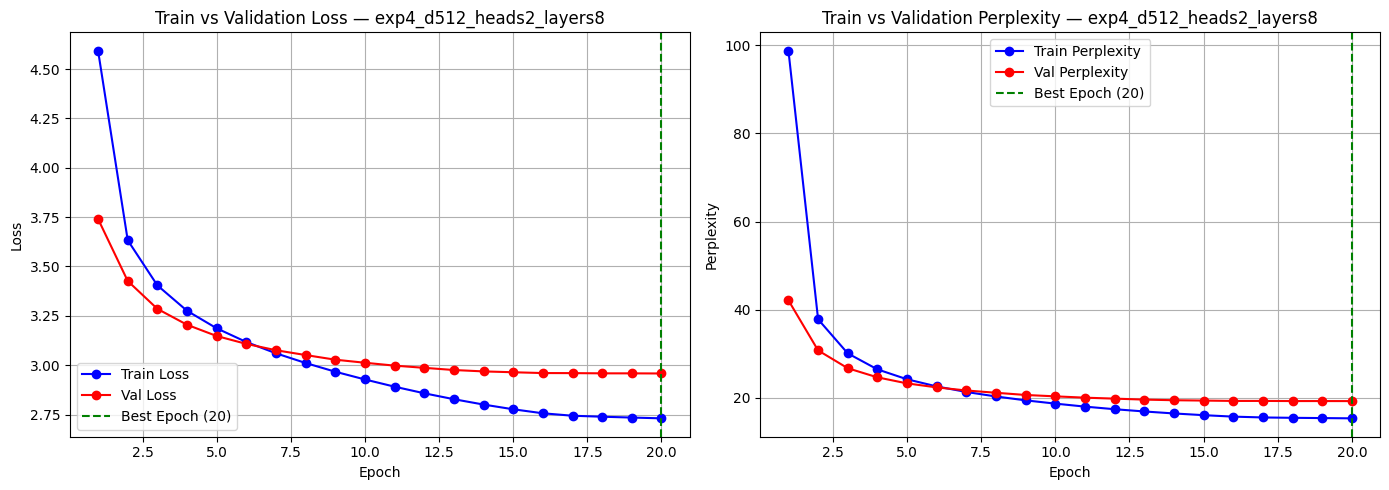

Loss curve saved to ../experiments/exp4_d512_heads2_layers8/checkpoints/loss_curve.png


In [42]:
import torch, os
import matplotlib.pyplot as plt
import pandas as pd

# --- Load all epoch data from checkpoints ---
results = []
for epoch in range(1, MAX_EPOCHS + 1):
    path = os.path.join(CHECKPOINT_DIR, f'epoch_{epoch}.pt')
    if os.path.exists(path):
        ckpt = torch.load(path, map_location='cpu', weights_only=False)
        results.append({
            'Epoch'           : epoch,
            'Train Loss'      : round(ckpt['train_loss'], 4),
            'Val Loss'        : round(ckpt['val_loss'],   4),
            'Train Perplexity': round(torch.exp(torch.tensor(ckpt['train_loss'])).item(), 2),
            'Val Perplexity'  : round(torch.exp(torch.tensor(ckpt['val_loss'])).item(),   2),
        })

df = pd.DataFrame(results)

# --- Find best epoch ---
best_idx = df['Val Loss'].idxmin()
best_row = df.loc[best_idx]

# --- Print summary table ---
print("=" * 65)
print(f"     TRAINING RESULTS — {EXPERIMENT_NAME}")
print("=" * 65)
print(df.to_string(index=False))
print("=" * 65)
print(f"  Best Epoch         : {int(best_row['Epoch'])}")
print(f"  Best Val Loss      : {best_row['Val Loss']}")
print(f"  Best Val Perplexity: {best_row['Val Perplexity']}")
print("=" * 65)

# --- Plot Loss & Perplexity ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df['Epoch'], df['Train Loss'], 'b-o', label='Train Loss')
ax1.plot(df['Epoch'], df['Val Loss'],   'r-o', label='Val Loss')
ax1.axvline(x=best_row['Epoch'], color='green', linestyle='--', label=f'Best Epoch ({int(best_row["Epoch"])})')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title(f'Train vs Validation Loss — {EXPERIMENT_NAME}')
ax1.legend(); ax1.grid(True)

ax2.plot(df['Epoch'], df['Train Perplexity'], 'b-o', label='Train Perplexity')
ax2.plot(df['Epoch'], df['Val Perplexity'],   'r-o', label='Val Perplexity')
ax2.axvline(x=best_row['Epoch'], color='green', linestyle='--', label=f'Best Epoch ({int(best_row["Epoch"])})')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Perplexity')
ax2.set_title(f'Train vs Validation Perplexity — {EXPERIMENT_NAME}')
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.savefig(f'{CHECKPOINT_DIR}/loss_curve.png', dpi=150)
plt.show()
print(f"Loss curve saved to {CHECKPOINT_DIR}/loss_curve.png")

## Cell 9 — Quick Generation Test
Load best model and generate a response to a sample symptom

In [43]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import sentencepiece as spm
import json, math

# --- Load config from experiment folder ---
with open(f'{EXP_DIR}/config.json', 'r') as f:
    config = json.load(f)

VOCAB_SIZE  = config['vocab_size']
MAX_SEQ_LEN = config['max_seq_len']
D_MODEL     = config['d_model']
N_HEADS     = config['n_heads']
N_LAYERS    = config['n_layers']
FFN_DIM     = config['ffn_dim']
PAD_ID      = config['pad_id']
EOS_ID      = config['eos_id']

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# --- Model definition ---
class Embeddings(nn.Module):
    def __init__(self, vocab_size, d_model, max_seq_len, pad_id, dropout=0.1):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_id)
        self.pos_emb   = nn.Embedding(max_seq_len, d_model)
        self.dropout   = nn.Dropout(dropout)
        self.d_model   = d_model
    def forward(self, x):
        seq_len   = x.size(1)
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)
        tok = self.token_emb(x)
        pos = self.pos_emb(positions)
        return self.dropout(tok * math.sqrt(self.d_model) + pos)

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.W_q     = nn.Linear(d_model, d_model)
        self.W_k     = nn.Linear(d_model, d_model)
        self.W_v     = nn.Linear(d_model, d_model)
        self.W_o     = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, causal_mask=None, pad_mask=None):
        B, T, _ = x.shape
        Q = self.W_q(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        K = self.W_k(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        V = self.W_v(x).view(B, T, self.n_heads, self.d_head).transpose(1, 2)
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_head)
        if causal_mask is not None:
            scores = scores.masked_fill(causal_mask == 0, float('-inf'))
        if pad_mask is not None:
            scores = scores.masked_fill(pad_mask.unsqueeze(1).unsqueeze(2) == 0, float('-inf'))
        attn = torch.nan_to_num(F.softmax(scores, dim=-1), nan=0.0)
        attn = self.dropout(attn)
        out  = torch.matmul(attn, V)
        return self.W_o(out.transpose(1, 2).contiguous().view(B, T, self.d_model))

class FeedForward(nn.Module):
    def __init__(self, d_model, ffn_dim, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, d_model),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        return self.net(x)

class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, ffn_dim, dropout=0.1):
        super().__init__()
        self.attn    = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn     = FeedForward(d_model, ffn_dim, dropout)
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x, causal_mask=None, pad_mask=None):
        x = x + self.dropout(self.attn(self.norm1(x), causal_mask, pad_mask))
        x = x + self.ffn(self.norm2(x))
        return x

class MedicalGPT(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, n_layers, ffn_dim,
                 max_seq_len, pad_id, dropout=0.1):
        super().__init__()
        self.pad_id     = pad_id
        self.embeddings = Embeddings(vocab_size, d_model, max_seq_len, pad_id, dropout)
        self.layers     = nn.ModuleList([
            DecoderLayer(d_model, n_heads, ffn_dim, dropout) for _ in range(n_layers)
        ])
        self.norm    = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size, bias=False)
        self.lm_head.weight = self.embeddings.token_emb.weight
    def make_causal_mask(self, seq_len, device):
        return torch.tril(torch.ones(seq_len, seq_len, device=device)).unsqueeze(0).unsqueeze(0)
    def forward(self, input_ids, attention_mask=None):
        B, T   = input_ids.shape
        x      = self.embeddings(input_ids)
        cmask  = self.make_causal_mask(T, input_ids.device)
        for layer in self.layers:
            x = layer(x, causal_mask=cmask, pad_mask=attention_mask)
        return self.lm_head(self.norm(x))

# --- Load best model from experiment folder ---
model = MedicalGPT(VOCAB_SIZE, D_MODEL, N_HEADS, N_LAYERS, FFN_DIM, MAX_SEQ_LEN, PAD_ID)
ckpt  = torch.load(f'{CHECKPOINT_DIR}/best_model.pt', map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
model.to(device)
model.eval()
print(f"✅ Model loaded from {CHECKPOINT_DIR}/best_model.pt")

# --- Load tokenizer ---
sp = spm.SentencePieceProcessor()
sp.Load('../tokenizer/medical_bpe.model')
print("✅ Tokenizer loaded!")

# --- Generation function ---
def generate(symptom_text, max_new_tokens=150, temperature=0.7, top_k=50):
    prompt = f"<patient> {symptom_text} <doctor>"
    input_ids = sp.Encode(prompt, out_type=int)
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    with torch.no_grad():
        for _ in range(max_new_tokens):
            logits = model(input_tensor)
            next_logits = logits[0, -1, :] / temperature
            top_k_vals, top_k_idx = torch.topk(next_logits, top_k)
            probs = torch.softmax(top_k_vals, dim=-1)
            next_token = top_k_idx[torch.multinomial(probs, 1)].view(1, 1)
            if next_token.item() == EOS_ID:
                break
            input_tensor = torch.cat([input_tensor, next_token], dim=1)
    output_ids = input_tensor[0].tolist()
    output_text = sp.Decode(output_ids)
    if '<doctor>' in output_text:
        output_text = output_text.split('<doctor>')[-1].strip()
    return output_text

# --- Test cases ---
test_cases = [
    "I have fever and headache for 3 days",
    "I am experiencing chest pain and shortness of breath",
    "I have a sore throat and runny nose",
]

print("\n" + "="*60)
print(f"   GENERATION TEST — {EXPERIMENT_NAME}")
print("="*60)
for symptom in test_cases:
    print(f"\nPatient : {symptom}")
    print(f"Doctor  : {generate(symptom)}")
    print("-"*60)

Using device: cuda
✅ Model loaded from ../experiments/exp4_d512_heads2_layers8/checkpoints/best_model.pt
✅ Tokenizer loaded!

   GENERATION TEST — exp4_d512_heads2_layers8

Patient : I have fever and headache for 3 days
Doctor  : I have read your query and here is my advice.Your symptoms are not suggestive of a serious condition.In my opinion you should consult a doctor and get a clinical examination done.I hope ts answer helps. Please get back if you have any further questions.
------------------------------------------------------------

Patient : I am experiencing chest pain and shortness of breath
Doctor  : welcome to . Breatng difficulty is typical for broncal asthma.Besides the symptoms you have written by you it may be a simple allergic asthma, and it is curable. When it is diagnosed you can get it treated.
------------------------------------------------------------

Patient : I have a sore throat and runny nose
Doctor  : Welcome to Forum, you have a sore throat that is sore th